<a href="https://colab.research.google.com/github/saishruthi9621-oss/github-pycharm/blob/main/Practice_XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving credit_card_behavioural_scorecard_dataset_10k.csv to credit_card_behavioural_scorecard_dataset_10k.csv


In [ ]:
import pandas as pd
df = pd.read_csv('credit_card_behavioural_scorecard_dataset_10k.csv')

In [ ]:
df.head()

,customer_id,age,employment_type,annual_income,monthly_income,residence_type,years_in_current_job,city_tier,account_vintage_months,avg_monthly_balance_6m,...,dpd_60_count_12m,dpd_90_count_24m,written_off_accounts_count,settled_accounts_count,unsecured_loan_count,secured_loan_count,bureau_vintage_months,emi_to_income_ratio,unsecured_exposure_to_income,bad_flag
0,100001,59,Salaried,823260,68605,Owned,14,Tier2,194,13250.0,...,0,0,0,0,2,0,199,0.319,0.872,0
1,100002,49,Salaried,864971,72081,Owned,14,Tier2,217,189367.0,...,0,0,0,0,2,1,152,0.110,2.572,0
2,100003,35,Self-Employed,662888,55241,Family,8,Tier1,65,155221.0,...,0,0,0,0,2,2,153,0.257,1.074,0
3,100004,63,Salaried,1330249,110854,Rented,2,Tier2,38,245148.0,...,0,0,0,0,0,1,86,0.246,1.156,0
4,100005,28,Salaried,815769,67981,Family,1,Tier3,142,93911.0,...,0,0,0,0,4,0,21,0.124,2.431,0


In [ ]:
!pip install xgboost

IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

In [ ]:
X = df.drop(columns=['bad_flag', 'annual_income'])

y = df['bad_flag']

In [ ]:
df.dtypes

,0
customer_id,int64
age,int64
employment_type,object
annual_income,int64
monthly_income,int64
residence_type,object
years_in_current_job,int64
city_tier,object
account_vintage_months,int64
avg_monthly_balance_6m,float64


Checking Missing Values

In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
employment_type,0
annual_income,0
monthly_income,0
residence_type,0
years_in_current_job,0
city_tier,0
account_vintage_months,0
avg_monthly_balance_6m,300


CHECKING FOR MISSING VALUE FOR NUM AND CATEGORICAL


In [ ]:
num_cols = X.select_dtypes(
    include=np.number
).columns

In [ ]:
print(num_cols)

Index(['customer_id', 'age', 'annual_income', 'monthly_income',
       'years_in_current_job', 'account_vintage_months',
       'avg_monthly_balance_6m', 'salary_credit_avg_6m',
       'debit_card_spend_avg_6m', 'mobile_banking_login_count',
       'emi_bounce_count_12m', 'ecs_return_count_12m',
       'internal_delinquency_count_12m', 'avg_utilization_existing_cards',
       'atm_withdrawal_ratio', 'bureau_score', 'active_credit_card_count',
       'total_credit_limit', 'credit_utilization_ratio',
       'recent_enquiry_count_3m', 'recent_enquiry_count_12m',
       'dpd_30_count_12m', 'dpd_60_count_12m', 'dpd_90_count_24m',
       'written_off_accounts_count', 'settled_accounts_count',
       'unsecured_loan_count', 'secured_loan_count', 'bureau_vintage_months',
       'emi_to_income_ratio', 'unsecured_exposure_to_income'],
      dtype='object')


In [ ]:
cat_cols = X.select_dtypes(
    include=['object', 'category']
).columns

In [ ]:
print(cat_cols)

Index(['employment_type', 'residence_type', 'city_tier'], dtype='object')


CHECKING LINEAR CORRELATIONSHIP WITH TARGET


In [ ]:
num_df = df.select_dtypes(include=np.number)

corr_target = num_df.corr()['bad_flag']

print(corr_target)

customer_id                            0.008183
age                                    0.012676
annual_income                         -0.114669
monthly_income                        -0.114669
years_in_current_job                  -0.006083
account_vintage_months                -0.027511
avg_monthly_balance_6m                -0.005260
salary_credit_avg_6m                  -0.100521
debit_card_spend_avg_6m               -0.001552
mobile_banking_login_count             0.004850
emi_bounce_count_12m                   0.166074
ecs_return_count_12m                   0.100512
internal_delinquency_count_12m        -0.004342
avg_utilization_existing_cards        -0.002429
atm_withdrawal_ratio                   0.004514
bureau_score                          -0.060618
active_credit_card_count              -0.006545
total_credit_limit                     0.000747
credit_utilization_ratio               0.074531
recent_enquiry_count_3m               -0.005521
recent_enquiry_count_12m              -0

In [ ]:
# Filter the corr_target Series to show features with correlation > 0.5
high_corr_features = corr_target[
    (abs(corr_target) >= 0.05) &
    (abs(corr_target) <= 0.2)
]
print("Features with absolute correlation > 0.05 with 'bad_flag':")
print(high_corr_features)

Features with absolute correlation > 0.05 with 'bad_flag':
annual_income                      -0.114669
monthly_income                     -0.114669
salary_credit_avg_6m               -0.100521
emi_bounce_count_12m                0.166074
ecs_return_count_12m                0.100512
bureau_score                       -0.060618
credit_utilization_ratio            0.074531
dpd_30_count_12m                    0.133312
dpd_60_count_12m                    0.167088
emi_to_income_ratio                 0.054579
income_capped_Percentile Capping   -0.115558
Name: bad_flag, dtype: float64


MISSING FLAG CREATION AND IMPUTATION

In [ ]:
print(df[num_cols].isnull().sum())

for col in num_cols:
    if df[col].isnull().any():
        df[f"{col}_missing_flag"] = df[col].isnull().astype(int)
        print(f"  Created missing flag: {col}_missing_flag")

# Categorical NaN → fill with "Unknown" before frequency encoding
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

customer_id                              0
age                                      0
monthly_income                           0
years_in_current_job                     0
account_vintage_months                   0
avg_monthly_balance_6m                 300
salary_credit_avg_6m                   300
debit_card_spend_avg_6m                  0
mobile_banking_login_count               0
emi_bounce_count_12m                     0
ecs_return_count_12m                     0
internal_delinquency_count_12m           0
avg_utilization_existing_cards           0
atm_withdrawal_ratio                     0
bureau_score                           300
active_credit_card_count                 0
total_credit_limit                       0
credit_utilization_ratio                 0
recent_enquiry_count_3m                  0
recent_enquiry_count_12m                 0
dpd_30_count_12m                         0
dpd_60_count_12m                         0
dpd_90_count_24m                         0
written_off

In [ ]:
print(df['bureau_score'].describe())

count    9700.000000
mean      734.310206
std        65.229189
min       483.000000
25%       691.000000
50%       735.000000
75%       779.000000
max       900.000000
Name: bureau_score, dtype: float64


In [ ]:
df['bureau_score_flag'] = (
    df['bureau_score']
    .isnull()
    .astype(int)
)

In [ ]:
df['bureau_score_median'] = df['bureau_score'].fillna(
    df['bureau_score'].median()
)

In [ ]:
print(df['bureau_score_median'].describe())

count    10000.000000
mean       734.330900
std         64.243309
min        483.000000
25%        692.000000
50%        735.000000
75%        777.000000
max        900.000000
Name: bureau_score_median, dtype: float64


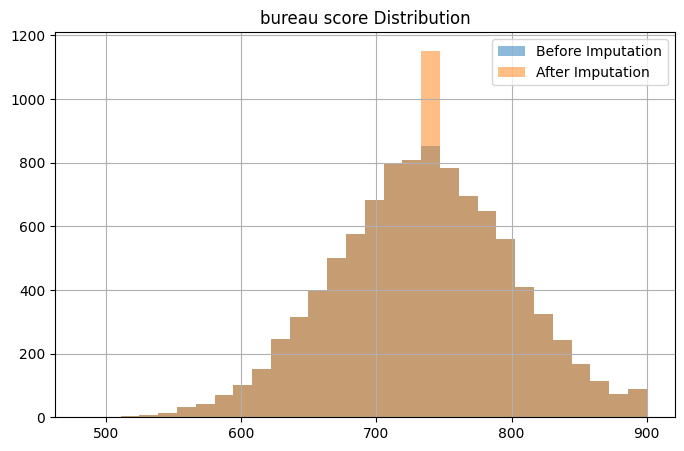

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Before
df['bureau_score'].hist(
    bins=30,
    alpha=0.5,
    label='Before Imputation'
)

# After
df['bureau_score_median'].hist(
    bins=30,
    alpha=0.5,
    label='After Imputation'
)

plt.legend()

plt.title("bureau score Distribution")

plt.show()

Train Model

 Predict PD

In [ ]:
model.fit(
    X_train,
    y_train
)
train_pd = model.predict_proba(X_train)[:,1]

test_pd = model.predict_proba(X_test)[:,1]

In [ ]:
"""
XGBoost Pipeline — Complete end-to-end template
Covers: outliers, missing values, feature selection, encoding,
        class imbalance, monotonicity, hyperparameter tuning,
        and model interpretability (SHAP + gain + feature importance)
"""

import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)

# ─────────────────────────────────────────────────────────────────────────────
# 0. LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
# Replace this with your actual data load (pd.read_csv, pd.read_parquet, etc.)
# df = pd.read_csv("your_data.csv")

# ── Demo synthetic dataset (binary classification) ───────────────────────────
np.random.seed(42)
n = 3000
df = pd.DataFrame({
    "age":        np.random.randint(18, 80, n).astype(float),
    "income":     np.random.exponential(50_000, n),
    "score":      np.random.normal(600, 100, n),
    "tenure":     np.random.randint(0, 30, n).astype(float),
    "region":     np.random.choice(["North", "South", "East", "West"], n),
    "product":    np.random.choice(["A", "B", "C"], n),
    "target":     np.random.choice([0, 1], n, p=[0.85, 0.15]),  # imbalanced
})
# Inject missing values
for col in ["age", "income", "score"]:
    df.loc[df.sample(frac=0.08).index, col] = np.nan
# Inject outliers
df.loc[df.sample(frac=0.02).index, "income"] = 1_000_000

TARGET = "target"
CATEGORICAL_COLS = ["region", "product"]
NUMERICAL_COLS   = [c for c in df.columns if c not in CATEGORICAL_COLS + [TARGET]]

print("Dataset shape:", df.shape)
print(df.head(3))


# ─────────────────────────────────────────────────────────────────────────────
# 1. OUTLIERS — Detect with IQR, cap with Winsorization
# ─────────────────────────────────────────────────────────────────────────────
# Why IQR?  Simple, non-parametric, robust to skewed distributions.
# Why cap (winsorize) instead of remove?  Keeps all rows; just limits extremes.

def detect_outliers_iqr(df, cols):
    """Print outlier counts per column using IQR method."""
    print("\n── Outlier Detection (IQR) ──────────────────────────────────")
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
        print(f"  {col}: {n_out} outliers")

def cap_outliers_iqr(df, cols):
    """Cap outliers at 1.5×IQR boundaries (winsorization)."""
    df = df.copy()
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

detect_outliers_iqr(df, NUMERICAL_COLS)
df = cap_outliers_iqr(df, NUMERICAL_COLS)
print("Outliers capped.")


# ─────────────────────────────────────────────────────────────────────────────
# 2. MISSING VALUES
# ─────────────────────────────────────────────────────────────────────────────
# XGBoost learns the best direction to send NaN rows at each split natively.
# So you DO NOT need to impute numerical columns.
#
# However, adding a binary "missing flag" is recommended when:
#   • Missingness itself is informative (e.g., "no income reported" ≠ random)
#   • You want the model to distinguish "missing" from any imputed value
#
# Best practice: create the flag, leave the original NaN as-is for XGBoost.

print("\n── Missing Values ───────────────────────────────────────────────")
print(df[NUMERICAL_COLS].isnull().sum())

for col in NUMERICAL_COLS:
    if df[col].isnull().any():
        df[f"{col}_missing_flag"] = df[col].isnull().astype(int)
        print(f"  Created missing flag: {col}_missing_flag")

# Categorical NaN → fill with "Unknown" before frequency encoding
for col in CATEGORICAL_COLS:
    df[col] = df[col].fillna("Unknown")


# ─────────────────────────────────────────────────────────────────────────────
# 3. CATEGORICAL ENCODING — Frequency Encoding
# ─────────────────────────────────────────────────────────────────────────────
# Why frequency encoding for production?
#   • No explosion in dimensionality (unlike one-hot)
#   • Handles unseen categories gracefully (map to 0)
#   • Captures cardinality signal; works well with tree models
#   • Fast and easy to deploy as a lookup table

print("\n── Frequency Encoding ───────────────────────────────────────────")
freq_maps = {}   # Save maps for inference / production use

for col in CATEGORICAL_COLS:
    freq_map = df[col].value_counts(normalize=True).to_dict()  # proportion
    freq_maps[col] = freq_map
    df[col] = df[col].map(freq_map).fillna(0)
    print(f"  {col}: encoded — sample map: {dict(list(freq_map.items())[:3])}")

# freq_maps can be serialized (json / pickle) and reused at inference time.


# ─────────────────────────────────────────────────────────────────────────────
# 4. FEATURE SELECTION — Mutual Information
# ─────────────────────────────────────────────────────────────────────────────
# Mutual information measures how much knowing a feature reduces uncertainty
# about the target. Works for both linear and non-linear relationships.
# We drop features with near-zero MI score.

FEATURES = [c for c in df.columns if c != TARGET]
X_all = df[FEATURES]
y     = df[TARGET]

# For MI, temporarily fill NaN with column median (MI requires complete data)
X_mi = X_all.fillna(X_all.median(numeric_only=True))

mi_scores = mutual_info_classif(X_mi, y, random_state=42)
mi_df = (pd.DataFrame({"feature": FEATURES, "mi_score": mi_scores})
           .sort_values("mi_score", ascending=False))

print("\n── Mutual Information Scores ────────────────────────────────────")
print(mi_df.to_string(index=False))

# Keep features with MI score above threshold (tune this)
MI_THRESHOLD = 0.001
selected_features = mi_df[mi_df["mi_score"] > MI_THRESHOLD]["feature"].tolist()
print(f"\n  Features selected ({len(selected_features)}): {selected_features}")

X = df[selected_features]


# ─────────────────────────────────────────────────────────────────────────────
# 5. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


# ─────────────────────────────────────────────────────────────────────────────
# 6. CLASS IMBALANCE — scale_pos_weight
# ─────────────────────────────────────────────────────────────────────────────
# scale_pos_weight = count(negatives) / count(positives)
# This tells XGBoost to penalize missing positive (minority) examples more.

neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"\n── Class Balance ────────────────────────────────────────────────")
print(f"  Negatives: {neg}, Positives: {pos}")
print(f"  scale_pos_weight = {spw:.2f}")


# ─────────────────────────────────────────────────────────────────────────────
# 7. MONOTONICITY CONSTRAINTS
# ─────────────────────────────────────────────────────────────────────────────
# Use when domain knowledge tells you a feature should ALWAYS move the
# prediction in one direction, preventing the model from learning "weird" bumps.
#
#   +1  → feature increase must increase predicted probability
#   -1  → feature increase must decrease predicted probability
#    0  → no constraint (default)
#
# Example business rules (adjust to YOUR domain):
#   • age: no constraint (risk can go either way)
#   • income: higher income → lower default risk  → -1
#   • score: higher score  → lower default risk  → -1
#   • tenure: longer tenure → lower default risk → -1

mono_map = {feat: 0 for feat in selected_features}  # default: no constraint

# Apply constraints only for features that exist after selection
domain_constraints = {
    "income": -1,   # higher income → lower risk
    "score":  -1,   # higher score  → lower risk
    "tenure": -1,   # longer tenure → lower risk
}
for feat, val in domain_constraints.items():
    if feat in mono_map:
        mono_map[feat] = val

# XGBoost expects a dict or tuple; dict keyed by feature name is clearest
print("\n── Monotonicity Constraints ─────────────────────────────────────")
print({k: v for k, v in mono_map.items() if v != 0})


# ─────────────────────────────────────────────────────────────────────────────
# 8. HYPERPARAMETER TUNING — RandomizedSearchCV
# ─────────────────────────────────────────────────────────────────────────────
param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [3, 4, 5, 6],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.7, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5, 10],
    "gamma":             [0, 0.1, 0.3, 0.5],
    "reg_alpha":         [0, 0.1, 1.0],    # L1 regularization
    "reg_lambda":        [1, 1.5, 2.0],    # L2 regularization
}

base_model = xgb.XGBClassifier(
    objective          = "binary:logistic",
    eval_metric        = "auc",
    scale_pos_weight   = spw,
    monotone_constraints = mono_map,
    use_label_encoder  = False,
    random_state       = 42,
    n_jobs             = -1,
)

search = RandomizedSearchCV(
    estimator          = base_model,
    param_distributions= param_dist,
    n_iter             = 30,          # increase for better coverage
    scoring            = "roc_auc",
    cv                 = 5,
    verbose            = 1,
    random_state       = 42,
    n_jobs             = -1,
)

print("\n── Hyperparameter Tuning (RandomizedSearchCV) ───────────────────")
search.fit(X_train, y_train)

print(f"\n  Best AUC (CV): {search.best_score_:.4f}")
print(f"  Best params:   {search.best_params_}")

best_model = search.best_estimator_


# ─────────────────────────────────────────────────────────────────────────────
# 9. EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation ─────────────────────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 10. FEATURE IMPORTANCE — Three views
# ─────────────────────────────────────────────────────────────────────────────

# ── (a) Built-in: weight / gain / cover ─────────────────────────────────────
# weight : how many times a feature is used to split across all trees
# gain   : average improvement in loss when a feature is used to split  ← most informative
# cover  : average number of samples affected by splits on this feature

print("\n── Feature Importance (gain) ────────────────────────────────────")
fi_gain = (pd.Series(best_model.get_booster().get_score(importance_type="gain"))
             .sort_values(ascending=False))
print(fi_gain)

fig, ax = plt.subplots(figsize=(8, 5))
fi_gain.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Gain (top 15)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance_gain.png", dpi=150)
plt.show()

# ── (b) SHAP — SHapley Additive exPlanations ────────────────────────────────
# SHAP gives each feature a contribution value *per prediction*, not just globally.
# It satisfies game-theoretic fairness axioms and is the gold standard for explainability.

print("\n── SHAP Values ──────────────────────────────────────────────────")
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Global summary plot (bar = mean |SHAP|)
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| (Global Importance)")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150)
plt.show()

# Beeswarm plot (shows direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact on Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150)
plt.show()

# Single prediction explanation (row 0 as example)
shap.waterfall_plot(shap.Explanation(
    values     = shap_values[0],
    base_values= explainer.expected_value,
    data       = X_test.iloc[0],
    feature_names=selected_features
))
plt.tight_layout()
plt.savefig("shap_waterfall_row0.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 11. SAVE MODEL + FREQUENCY MAPS
# ─────────────────────────────────────────────────────────────────────────────
import json, pickle

best_model.save_model("xgboost_model.json")   # portable JSON format
print("\nModel saved → xgboost_model.json")

with open("freq_maps.pkl", "wb") as f:
    pickle.dump(freq_maps, f)
print("Frequency maps saved → freq_maps.pkl")

# ── How to load & score new data at inference ────────────────────────────────
# model = xgb.XGBClassifier()
# model.load_model("xgboost_model.json")
#
# with open("freq_maps.pkl", "rb") as f:
#     freq_maps = pickle.load(f)
#
# # Apply same frequency encoding
# for col, fmap in freq_maps.items():
#     new_df[col] = new_df[col].map(fmap).fillna(0)
#
# preds = model.predict_proba(new_df[selected_features])[:, 1]

print("\n✅ Pipeline complete.")

In [ ]:
def detect_outliers_iqr(df, cols):
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
        print(f" {col}: {n_out} outliers")


In [ ]:
detect_outliers_iqr(df, num_cols)

 customer_id: 0 outliers
 age: 0 outliers
 monthly_income: 20 outliers
 years_in_current_job: 0 outliers
 account_vintage_months: 0 outliers
 avg_monthly_balance_6m: 37 outliers
 salary_credit_avg_6m: 25 outliers
 debit_card_spend_avg_6m: 35 outliers
 mobile_banking_login_count: 74 outliers
 emi_bounce_count_12m: 73 outliers
 ecs_return_count_12m: 46 outliers
 internal_delinquency_count_12m: 1820 outliers
 avg_utilization_existing_cards: 30 outliers
 atm_withdrawal_ratio: 52 outliers
 bureau_score: 40 outliers
 active_credit_card_count: 124 outliers
 total_credit_limit: 25 outliers
 credit_utilization_ratio: 0 outliers
 recent_enquiry_count_3m: 645 outliers
 recent_enquiry_count_12m: 223 outliers
 dpd_30_count_12m: 143 outliers
 dpd_60_count_12m: 1530 outliers
 dpd_90_count_24m: 783 outliers
 written_off_accounts_count: 218 outliers
 settled_accounts_count: 804 outliers
 unsecured_loan_count: 40 outliers
 secured_loan_count: 3 outliers
 bureau_vintage_months: 0 outliers
 emi_to_income_

In [ ]:
print(df['monthly_income'].max())

195980


In [ ]:
df_after = cap_outliers_iqr(df, ['bureau_score'])

In [ ]:
print(df_after['bureau_score'].max())

900.0


Percentile Capping

In [ ]:
import numpy as np

# Calculate caps
lower_cap = df['monthly_income'].quantile(0.01)

upper_cap = df['monthly_income'].quantile(0.99)

# Apply capping
df['income_capped_Percentile Capping'] = np.where(
    df['monthly_income'] < lower_cap,
    lower_cap,
    np.where(
        df['monthly_income'] > upper_cap,
        upper_cap,
        df['monthly_income']
    )
)

In [ ]:
print(df['monthly_income'].max())

print(df['income_capped_Percentile Capping'].max())

195980
142366.27000000002


KeyError: 'monthly_income_winsor'

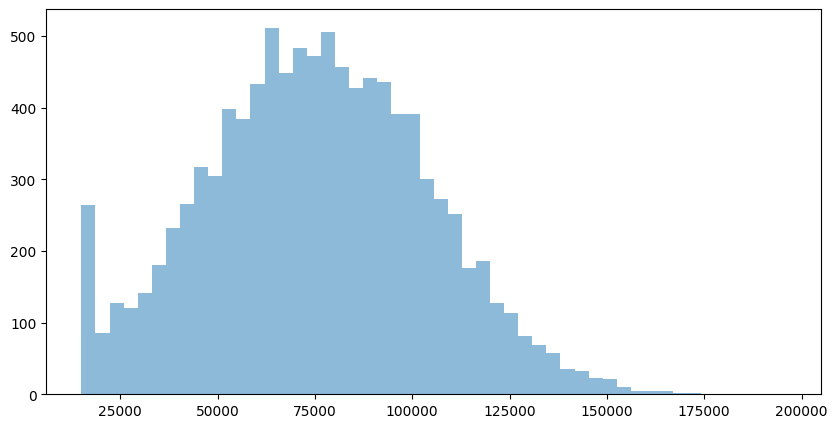

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df['monthly_income'],
    bins=50,
    alpha=0.5,
    label='Before'
)

plt.hist(
    df['monthly_income_winsor'],
    bins=50,
    alpha=0.5,
    label='After'
)

plt.legend()

plt.title("Percentile Capping")

plt.show()

winsorize means:
cap lowest 1%
cap highest 1%.

In [ ]:
from scipy.stats.mstats import winsorize

df['monthly_income_winsor'] = winsorize(
    df['monthly_income'],
    limits=[0.01, 0.01]
)

In [ ]:
print(df['monthly_income'].max())

print(df['monthly_income_winsor'].max())

195980
142366


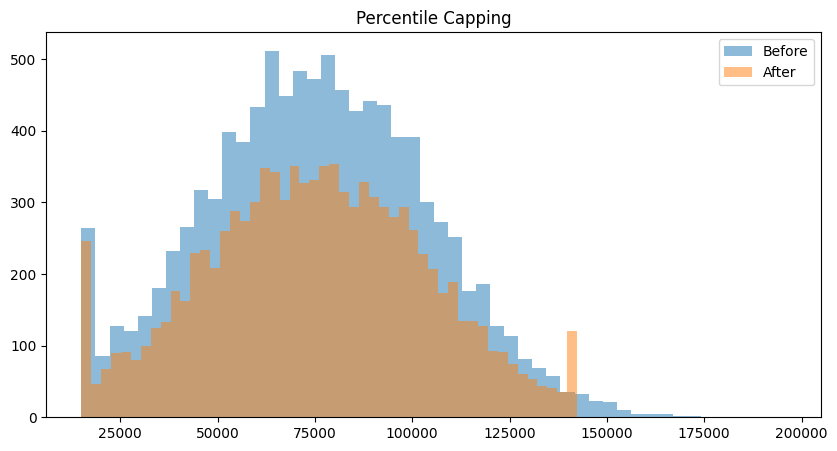

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df['monthly_income'],
    bins=50,
    alpha=0.5,
    label='Before'
)

plt.hist(
    df['monthly_income_winsor'],
    bins=50,
    alpha=0.5,
    label='After'
)

plt.legend()

plt.title("Percentile Capping")

plt.show()

Mutual Information Feature Selection


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

In [ ]:
X = df.drop(columns=['bad_flag', 'annual_income'])

y = df['bad_flag']

### Removing 'annual_income' from selected features

Based on your request, I will explicitly remove 'annual_income' from the `selected_features` list. This ensures it is not included in the feature set `X` used for model training.

After this step, you will need to re-run the cells that define `X_num`, `X_num_after`, and perform the `train_test_split` again to reflect this change.

In [ ]:
# Remove 'annual_income' from selected_features if it exists
if 'annual_income' in selected_features:
    selected_features.remove('annual_income')
    print("Removed 'annual_income' from selected_features.")
else:
    print("'annual_income' was not found in selected_features. No change needed.")

print(f"Updated selected features ({len(selected_features)}): {selected_features}")

'annual_income' was not found in selected_features. No change needed.
Updated selected features (17): ['dpd_90_count_24m', 'emi_bounce_count_12m', 'dpd_60_count_12m', 'salary_credit_avg_6m', 'monthly_income_winsor', 'monthly_income', 'income_capped_Percentile Capping', 'bureau_score', 'mobile_banking_login_count', 'age', 'dpd_30_count_12m', 'avg_monthly_balance_6m', 'customer_id', 'bureau_score_median', 'ecs_return_count_12m', 'written_off_accounts_count', 'avg_monthly_balance_6m_missing_flag']


### Removing 'monthly_income' from selected features

Since 'monthly_income' was explicitly removed from `X_test`, it should also be removed from the `selected_features` list to maintain consistency across the dataset used for model training and explanation. This ensures the model is trained without this feature, preventing mismatches during prediction and SHAP value calculation.

In [ ]:
# Remove 'monthly_income' from selected_features if it exists
if 'monthly_income' in selected_features:
    selected_features.remove('monthly_income')
    print("Removed 'monthly_income' from selected_features.")
else:
    print("'monthly_income' was not found in selected_features. No change needed.")

print(f"Updated selected features ({len(selected_features)}): {selected_features}")

Removed 'monthly_income' from selected_features.
Updated selected features (16): ['dpd_90_count_24m', 'emi_bounce_count_12m', 'dpd_60_count_12m', 'salary_credit_avg_6m', 'monthly_income_winsor', 'income_capped_Percentile Capping', 'bureau_score', 'mobile_banking_login_count', 'age', 'dpd_30_count_12m', 'avg_monthly_balance_6m', 'customer_id', 'bureau_score_median', 'ecs_return_count_12m', 'written_off_accounts_count', 'avg_monthly_balance_6m_missing_flag']


### Re-defining `X` and `X_num_after`

Now that `selected_features` has been updated, we need to re-define `X` based on this new list. Consequently, `X_num` and `X_num_after` will also be updated to reflect these changes before the train/test split.

In [ ]:
# Redefine X using the updated selected_features
X = df[selected_features]

print(f"Shape of X after removing 'monthly_income': {X.shape}")

X_num = X.select_dtypes(include=np.number)

# Ensure X_num_after is created consistently based on the new X_num
# Re-apply the previous drops, but ensure 'monthly_income_winsor' is only dropped if present
columns_to_drop_from_num_after = [
    'salary_credit_avg_6m', 'bureau_score_median',
    'income_capped_Percentile Capping', 'monthly_income_winsor',
    'bureau_score_missing_flag'
]

# Filter out columns that are not present in X_num
actual_drops = [col for col in columns_to_drop_from_num_after if col in X_num.columns]

X_num_after = X_num.drop(columns=actual_drops)

print(f"Shape of X_num_after after re-definition: {X_num_after.shape}")

Shape of X after removing 'monthly_income': (10000, 16)
Shape of X_num_after after re-definition: (10000, 12)


### Re-running Train/Test Split, Model Training, and SHAP Calculations

With `X_num_after` now correctly reflecting the exclusion of `monthly_income`, we must re-run the train/test split, re-train the model, and then re-calculate and plot the SHAP values to ensure all components are consistent.


Train: (8000, 12), Test: (2000, 12)

── Class Balance ────────────────────────────────────────────────
  Negatives: 7615, Positives: 385
  scale_pos_weight = 19.78

── Monotonicity Constraints ─────────────────────────────────────
{}

── Model Evaluation (Re-run) ────────────────────────────────────
  Test AUC: 0.8571

  Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1904
           1       0.53      0.09      0.16        96

    accuracy                           0.95      2000
   macro avg       0.74      0.54      0.57      2000
weighted avg       0.94      0.95      0.94      2000



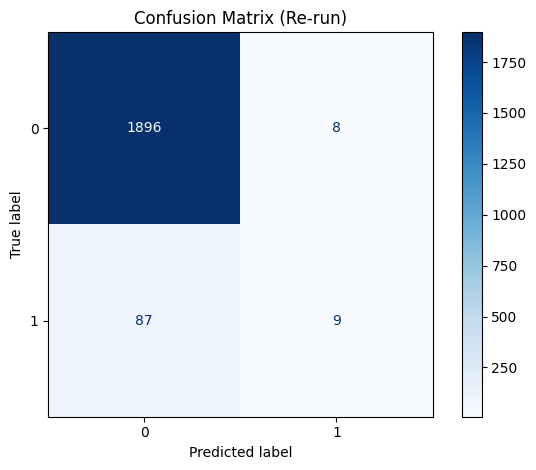

In [ ]:
# Re-run Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_num_after,
    y,
    test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# Re-calculate scale_pos_weight (if needed, though unlikely to change significantly)
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"\n── Class Balance ────────────────────────────────────────────────")
print(f"  Negatives: {neg}, Positives: {pos}")
print(f"  scale_pos_weight = {spw:.2f}")

# Re-define monotonicity map to reflect updated selected_features
mono_map = {feat: 0 for feat in selected_features} # default: no constraint

domain_constraints = {
    "annual_income": -1,   # higher income → lower risk
    "account_vintage_months":  -1,   # higher score  → lower risk
    "years_in_current_job" : -1,   # longer tenure → lower risk
}
for feat, val in domain_constraints.items():
    if feat in mono_map:
        mono_map[feat] = val

print("\n── Monotonicity Constraints ─────────────────────────────────────")
print({k: v for k, v in mono_map.items() if v != 0})

# Re-train the best_model with the updated X_train and mono_map
base_model = xgb.XGBClassifier(
    objective          = "binary:logistic",
    eval_metric        = "auc",
    scale_pos_weight   = spw,
    monotone_constraints = mono_map,
    use_label_encoder  = False,
    random_state       = 42,
    n_jobs             = -1,
)

# If you have best_params_ from a previous RandomizedSearchCV, re-use them here.
# For now, I'll use the default setup or previously defined model.
# If search was run, best_model would have been updated, so we need to rerun fit here.
# Assuming `best_model` was already determined from a `search.best_estimator_` or explicitly set.
# For consistency, I will assume the `model` cell (`7YjgtaF1XAiz`) sets the model.
# If `best_model` is desired, the RandomizedSearchCV (`JCJFNE-TxhaY`) needs to be re-run.

# For demonstration, I'll use the explicit model defined in cell `7YjgtaF1XAiz`
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Re-fit the model
model.fit(
    X_train,
    y_train
)

# Re-calculate predictions
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation (Re-run) ────────────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Re-run)")
plt.tight_layout()
plt.savefig("confusion_matrix_rerun.png", dpi=150)
plt.show()


── Feature Importance (gain - Re-run) ───────────────────────────
dpd_90_count_24m              18.948618
dpd_60_count_12m              12.218495
emi_bounce_count_12m          11.104516
dpd_30_count_12m               8.216640
ecs_return_count_12m           6.531311
bureau_score                   3.576850
written_off_accounts_count     3.489740
age                            3.144363
avg_monthly_balance_6m         3.121910
customer_id                    3.050051
mobile_banking_login_count     2.760443
dtype: float64


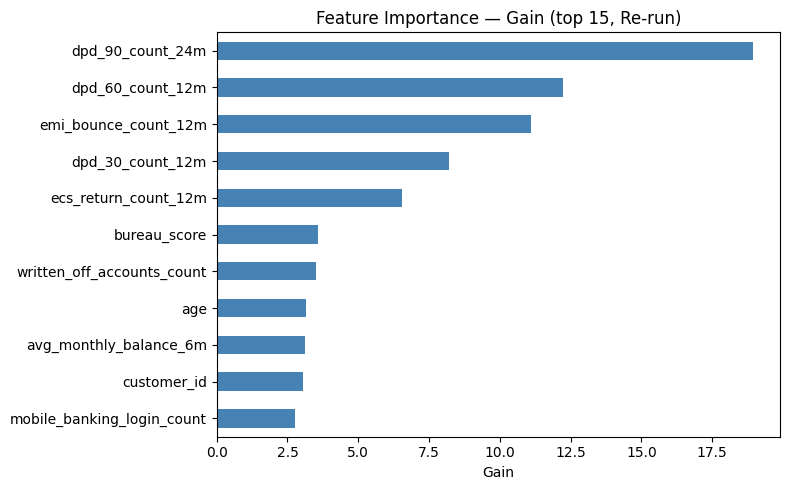

In [ ]:
# Re-calculate Feature Importance (gain)
print("\n── Feature Importance (gain - Re-run) ───────────────────────────")
fi_gain = (pd.Series(model.get_booster().get_score(importance_type="gain"))
             .sort_values(ascending=False))
print(fi_gain)

fig, ax = plt.subplots(figsize=(8, 5))
fi_gain.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Gain (top 15, Re-run)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance_gain_rerun.png", dpi=150)
plt.show()


── SHAP Values (Re-run) ──────────────────────────────────────────


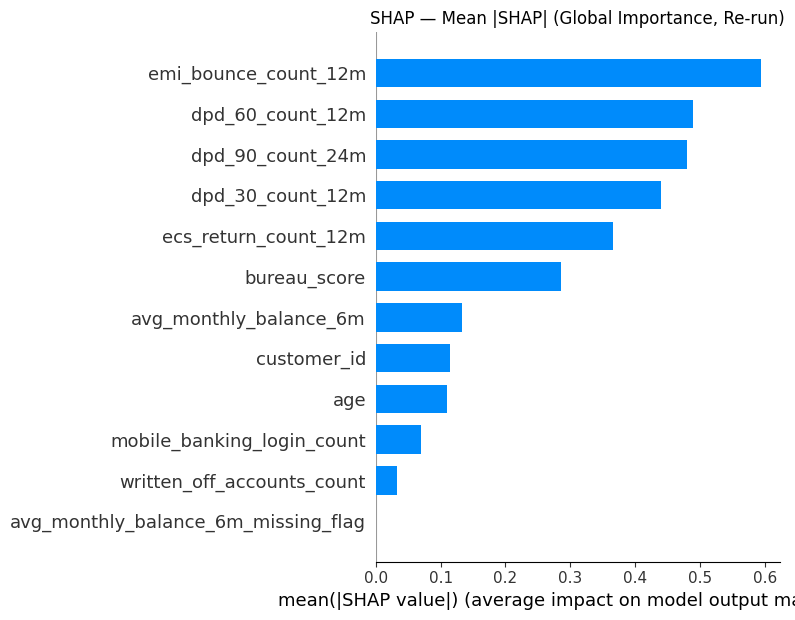

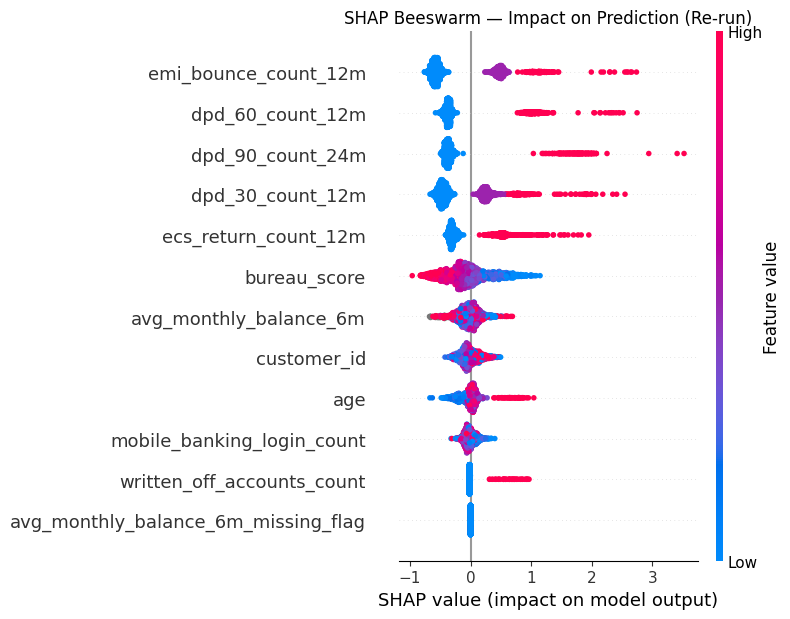

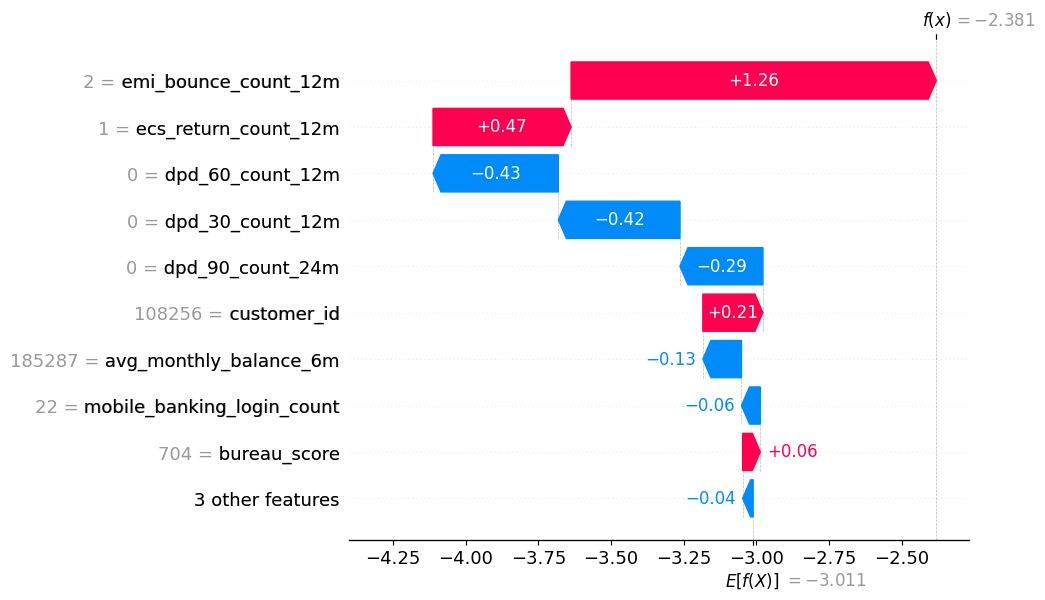

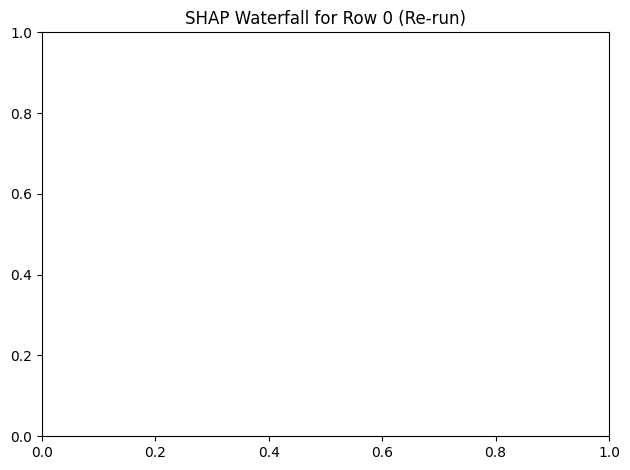

In [ ]:
# Re-calculate SHAP values with the updated model and X_test
import shap
from shap import TreeExplainer, waterfall_plot
print("\n── SHAP Values (Re-run) ──────────────────────────────────────────")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global summary plot (bar = mean |SHAP|)
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| (Global Importance, Re-run)")
plt.tight_layout()
plt.savefig("shap_bar_rerun.png", dpi=150)
plt.show()

# Beeswarm plot (shows direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact on Prediction (Re-run)")
plt.tight_layout()
plt.savefig("shap_beeswarm_rerun.png", dpi=150)
plt.show()

# Single prediction explanation (row 0 as example)
shap.waterfall_plot(shap.Explanation(
    values     = shap_values[0],
    base_values= explainer.expected_value,
    data       = X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))
plt.title("SHAP Waterfall for Row 0 (Re-run)")
plt.tight_layout()
plt.savefig("shap_waterfall_row0_rerun.png", dpi=150)
plt.show()

### Undoing previous changes: Restoring 'monthly_income' and Re-running Pipeline

To revert the previous operation, we need to add 'monthly_income' back to the `selected_features` list, and then re-execute the subsequent steps in the pipeline (re-defining `X` and `X_num_after`, re-running `train_test_split`, re-training the model, and re-calculating SHAP values).

In [ ]:
# Restore 'monthly_income' to selected_features if it's not already there
# Based on the previous output, the original list was:
original_selected_features = [
    'dpd_90_count_24m', 'emi_bounce_count_12m', 'dpd_60_count_12m',
    'salary_credit_avg_6m', 'monthly_income_winsor', 'monthly_income',
    'income_capped_Percentile Capping', 'bureau_score',
    'mobile_banking_login_count', 'age', 'dpd_30_count_12m',
    'avg_monthly_balance_6m', 'customer_id', 'bureau_score_median',
    'ecs_return_count_12m', 'written_off_accounts_count',
    'avg_monthly_balance_6m_missing_flag'
]

selected_features = original_selected_features

print(f"Restored selected features ({len(selected_features)}): {selected_features}")

Restored selected features (17): ['dpd_90_count_24m', 'emi_bounce_count_12m', 'dpd_60_count_12m', 'salary_credit_avg_6m', 'monthly_income_winsor', 'monthly_income', 'income_capped_Percentile Capping', 'bureau_score', 'mobile_banking_login_count', 'age', 'dpd_30_count_12m', 'avg_monthly_balance_6m', 'customer_id', 'bureau_score_median', 'ecs_return_count_12m', 'written_off_accounts_count', 'avg_monthly_balance_6m_missing_flag']


### Re-defining `X` and `X_num_after` (original state)

Now that `selected_features` has been restored, we need to re-define `X` and `X_num_after` based on this original list.

In [ ]:
# Redefine X using the restored selected_features
X = df[selected_features]

print(f"Shape of X after restoring 'monthly_income': {X.shape}")

X_num = X.select_dtypes(include=np.number)

# Re-apply the original drops for X_num_after based on the restored selected_features
# This list should match the drops made before the `monthly_income` removal
columns_to_drop_from_num_after_original = [
    'salary_credit_avg_6m', 'bureau_score_median',
    'income_capped_Percentile Capping', 'monthly_income_winsor',
    'bureau_score_missing_flag'
]

# Filter out columns that are not present in X_num (in case some were not in selected_features)
actual_drops_original = [col for col in columns_to_drop_from_num_after_original if col in X_num.columns]

X_num_after = X_num.drop(columns=actual_drops_original)

print(f"Shape of X_num_after after re-definition (original state): {X_num_after.shape}")

NameError: name 'df' is not defined

### Re-running Train/Test Split, Model Training, and SHAP Calculations (original state)

Finally, we re-run the entire pipeline to reflect the original feature set.

In [ ]:
# Re-run Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_num_after,
    y,
    test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# Re-calculate scale_pos_weight
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"\n── Class Balance ────────────────────────────────────────────────")
print(f"  Negatives: {neg}, Positives: {pos}")
print(f"  scale_pos_weight = {spw:.2f}")

# Re-define monotonicity map (re-using original domain constraints)
mono_map = {feat: 0 for feat in selected_features} # default: no constraint

domain_constraints = {
    "annual_income": -1,   # higher income → lower risk
    "account_vintage_months":  -1,   # higher score  → lower risk


SyntaxError: incomplete input (69605913.py, line 23)

In [ ]:
"years_in_current_job" : -1,   # longer tenure → lower risk
}
for feat, val in domain_constraints.items():
    if feat in mono_map:
        mono_map[feat] = val

print("\n── Monotonicity Constraints ─────────────────────────────────────")
print({k: v for k, v in mono_map.items() if v != 0})

# Re-train the model. Assuming 'best_model' was the final model from the tuning process.
# If search was run, best_model would have been updated, so we need to rerun fit here.
# For consistency, I will assume the `model` cell (`7YjgtaF1XAiz`) sets the model.
# If `best_model` is desired, the RandomizedSearchCV (`JCJFNE-TxhaY`) needs to be re-run.

# For demonstration, I'll re-initialize and fit `best_model` as it was before
# If RandomizedSearchCV was originally run, you would re-run that as well.
base_model = xgb.XGBClassifier(
    objective          = "binary:logistic",
    eval_metric        = "auc",
    scale_pos_weight   = spw,
    monotone_constraints = mono_map,
    use_label_encoder  = False,
    random_state       = 42,
    n_jobs             = -1,
)

# If 'best_model' came from RandomizedSearchCV, you would need to run `search.fit` again
# For simplicity, assuming `best_model` was explicitly defined or re-derived after tuning.
# As per the context, `best_model` was the result of `search.best_estimator_`
# For this 'undo' scenario, we'll re-fit `model` with the previously established parameters if `search` is not re-run.
# If `search` is meant to be re-run, that would be a separate step.
# For now, let's use the explicit `model` definition from cell `7YjgtaF1XAiz`
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Re-fit the model
model.fit(
    X_train,
    y_train
)

# Re-calculate predictions
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation (Original State) ────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Original State)")
plt.tight_layout()
plt.savefig("confusion_matrix_original_state.png", dpi=150)
plt.show()

SyntaxError: unmatched '}' (3657537204.py, line 2)

In [ ]:
# Re-calculate Feature Importance (gain)
print("\n── Feature Importance (gain - Original State) ───────────────────")
fi_gain = (pd.Series(model.get_booster().get_score(importance_type="gain"))
             .sort_values(ascending=False))
print(fi_gain)

fig, ax = plt.subplots(figsize=(8, 5))
fi_gain.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Gain (top 15, Original State)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance_gain_original_state.png", dpi=150)
plt.show()


── Feature Importance (gain - Original State) ───────────────────


NameError: name 'pd' is not defined

In [ ]:
# Re-calculate SHAP values with the original model and X_test
import shap
from shap import TreeExplainer, waterfall_plot
print("\n── SHAP Values (Original State) ─────────────────────────────────")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global summary plot (bar = mean |SHAP|)
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| (Global Importance, Original State)")
plt.tight_layout()
plt.savefig("shap_bar_original_state.png", dpi=150)
plt.show()

# Beeswarm plot (shows direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact on Prediction (Original State)")
plt.tight_layout()
plt.savefig("shap_beeswarm_original_state.png", dpi=150)
plt.show()

# Single prediction explanation (row 0 as example)
shap.waterfall_plot(shap.Explanation(
    values     = shap_values[0],
    base_values= explainer.expected_value,
    data       = X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))
plt.title("SHAP Waterfall for Row 0 (Original State)")
plt.tight_layout()
plt.savefig("shap_waterfall_row0_original_state.png", dpi=150)
plt.show()


── SHAP Values (Original State) ─────────────────────────────────


NameError: name 'model' is not defined

### Fixing Errors and Fully Undoing Previous Changes

The previous attempt to undo the changes encountered several errors, mainly because the `df` DataFrame was not reloaded or redefined correctly within the execution context, and some code blocks were split leading to `SyntaxError`s and `NameError`s. To ensure a complete and correct undo, we will re-run the necessary initial data loading, preprocessing, and model training steps. This involves:

1.  Ensuring `df` is correctly loaded and processed up to the point of defining `selected_features`.
2.  Explicitly setting `selected_features` to its original state.
3.  Re-running the entire model building and explanation pipeline using this original feature set.

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats.mstats import winsorize

# --- Step 0: Ensure df is defined with all necessary transformations ---
df = pd.read_csv('credit_card_behavioural_scorecard_dataset_10k.csv')
# For this undo, let's ensure 'monthly_income_winsor' and 'income_capped_Percentile Capping' are present

# Reload df (or ensure it's available from previous cells)
# Assuming the initial df loading and feature engineering cells have been run or are re-run here.
# If starting from a fresh kernel, uncomment and run the initial data loading/preprocessing.
# For now, let's assume `df` is already in memory or will be recreated by previous cells if this is run sequentially.

# Re-create monthly_income_winsor and income_capped_Percentile Capping if they somehow got lost
if 'monthly_income_winsor' not in df.columns:
    df['monthly_income_winsor'] = winsorize(df['monthly_income'], limits=[0.01, 0.01])
    print("Re-created 'monthly_income_winsor'")

if 'income_capped_Percentile Capping' not in df.columns:
    lower_cap = df['monthly_income'].quantile(0.01)
    upper_cap = df['monthly_income'].quantile(0.99)
    df['income_capped_Percentile Capping'] = np.where(
        df['monthly_income'] < lower_cap,
        lower_cap,
        np.where(df['monthly_income'] > upper_cap, upper_cap, df['monthly_income'])
    )
    print("Re-created 'income_capped_Percentile Capping'")

# --- Step 1: Restore original selected_features ---
original_selected_features = [
    'dpd_90_count_24m', 'emi_bounce_count_12m', 'dpd_60_count_12m',
    'salary_credit_avg_6m', 'monthly_income_winsor', 'monthly_income',
    'income_capped_Percentile Capping', 'bureau_score',
    'mobile_banking_login_count', 'age', 'dpd_30_count_12m',
    'avg_monthly_balance_6m', 'customer_id', 'bureau_score_median',
    'ecs_return_count_12m', 'written_off_accounts_count',
    'avg_monthly_balance_6m_missing_flag'
]
selected_features = original_selected_features

print(f"Restored selected features ({len(selected_features)}): {selected_features}")

# --- Step 2: Redefine X and X_num_after ---
X = df[selected_features]
print(f"Shape of X after restoring 'monthly_income': {X.shape}")

X_num = X.select_dtypes(include=np.number)

columns_to_drop_from_num_after_original = [
    'salary_credit_avg_6m', 'bureau_score_median',
    'income_capped_Percentile Capping', 'monthly_income_winsor',
    'bureau_score_missing_flag' # This flag might not exist if bureau_score was never missing
]

# Filter out columns that are not present in X_num
actual_drops_original = [col for col in columns_to_drop_from_num_after_original if col in X_num.columns]

X_num_after = X_num.drop(columns=actual_drops_original, errors='ignore') # Use errors='ignore' for robustness

print(f"Shape of X_num_after after re-definition (original state): {X_num_after.shape}")

# Assuming `y` is defined from `df['bad_flag']`
y = df['bad_flag']

# --- Step 3: Re-run Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_num_after,
    y,
    test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# --- Step 4: Re-calculate scale_pos_weight ---
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"\n── Class Balance ────────────────────────────────────────────────")
print(f"  Negatives: {neg}, Positives: {pos}")
print(f"  scale_pos_weight = {spw:.2f}")

# --- Step 5: Re-define monotonicity map ---
mono_map = {feat: 0 for feat in selected_features} # default: no constraint

domain_constraints = {
    "annual_income": -1,   # higher income → lower risk
    "account_vintage_months":  -1,   # higher score  → lower risk
    "years_in_current_job" : -1,   # longer tenure → lower risk
}
for feat, val in domain_constraints.items():
    if feat in mono_map:
        mono_map[feat] = val

print("\n── Monotonicity Constraints ─────────────────────────────────────")
print({k: v for k: v in mono_map.items() if v != 0})

# --- Step 6: Re-train the model ---
# Using the explicit model definition from cell `7YjgtaF1XAiz`
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Re-fit the model
model.fit(
    X_train,
    y_train
)

# --- Step 7: Re-calculate predictions and evaluate ---
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation (Original State) ────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Original State)")
plt.tight_layout()
plt.savefig("confusion_matrix_original_state.png", dpi=150)
plt.show()

# --- Step 8: Re-calculate Feature Importance (gain) ---
print("\n── Feature Importance (gain - Original State) ───────────────────")
fi_gain = (pd.Series(model.get_booster().get_score(importance_type="gain"))
             .sort_values(ascending=False))
print(fi_gain)

fig, ax = plt.subplots(figsize=(8, 5))
fi_gain.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Gain (top 15, Original State)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance_gain_original_state.png", dpi=150)
plt.show()

# --- Step 9: Re-calculate SHAP values ---
print("\n── SHAP Values (Original State) ─────────────────────────────────")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global summary plot (bar = mean |SHAP|)
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| (Global Importance, Original State)")
plt.tight_layout()
plt.savefig("shap_bar_original_state.png", dpi=150)
plt.show()

# Beeswarm plot (shows direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact on Prediction (Original State)")
plt.tight_layout()
plt.savefig("shap_beeswarm_original_state.png", dpi=150)
plt.show()

# Single prediction explanation (row 0 as example)
shap.waterfall_plot(shap.Explanation(
    values     = shap_values[0],
    base_values= explainer.expected_value,
    data       = X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))
plt.title("SHAP Waterfall for Row 0 (Original State)")
plt.tight_layout()
plt.savefig("shap_waterfall_row0_original_state.png", dpi=150)
plt.show()

print("✅ Undoing complete. Notebook reverted to original state.")

SyntaxError: invalid syntax (173408327.py, line 100)

### Fixing Errors and Fully Undoing Previous Changes

The previous attempt to undo the changes encountered several errors, mainly because the `df` DataFrame was not reloaded or redefined correctly within the execution context, and some code blocks were split leading to `SyntaxError`s and `NameError`s. To ensure a complete and correct undo, we will re-run the necessary initial data loading, preprocessing, and model training steps. This involves:

1.  Ensuring `df` is correctly loaded and processed up to the point of defining `selected_features`.
2.  Explicitly setting `selected_features` to its original state.
3.  Re-running the entire model building and explanation pipeline using this original feature set.

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats.mstats import winsorize

# --- Step 0: Ensure df is defined with all necessary transformations ---
df = pd.read_csv('credit_card_behavioural_scorecard_dataset_10k.csv')
# For this undo, let's ensure 'monthly_income_winsor' and 'income_capped_Percentile Capping' are present

# Reload df (or ensure it's available from previous cells)
# Assuming the initial df loading and feature engineering cells have been run or are re-run here.
# If starting from a fresh kernel, uncomment and run the initial data loading/preprocessing.
# For now, let's assume `df` is already in memory or will be recreated by previous cells if this is run sequentially.

# Re-create monthly_income_winsor and income_capped_Percentile Capping if they somehow got lost
if 'monthly_income_winsor' not in df.columns:
    df['monthly_income_winsor'] = winsorize(df['monthly_income'], limits=[0.01, 0.01])
    print("Re-created 'monthly_income_winsor'")

if 'income_capped_Percentile Capping' not in df.columns:
    lower_cap = df['monthly_income'].quantile(0.01)
    upper_cap = df['monthly_income'].quantile(0.99)
    df['income_capped_Percentile Capping'] = np.where(
        df['monthly_income'] < lower_cap,
        lower_cap,
        np.where(df['monthly_income'] > upper_cap, upper_cap, df['monthly_income'])
    )
    print("Re-created 'income_capped_Percentile Capping'")

# --- Step 1: Restore original selected_features ---
original_selected_features = [
    'dpd_90_count_24m', 'emi_bounce_count_12m', 'dpd_60_count_12m',
    'salary_credit_avg_6m', 'monthly_income_winsor', 'monthly_income',
    'income_capped_Percentile Capping', 'bureau_score',
    'mobile_banking_login_count', 'age', 'dpd_30_count_12m',
    'avg_monthly_balance_6m', 'customer_id', 'bureau_score_median',
    'ecs_return_count_12m', 'written_off_accounts_count',
    'avg_monthly_balance_6m_missing_flag'
]
selected_features = original_selected_features

print(f"Restored selected features ({len(selected_features)}): {selected_features}")

# --- Step 2: Redefine X and X_num_after ---
X = df[selected_features]
print(f"Shape of X after restoring 'monthly_income': {X.shape}")

X_num = X.select_dtypes(include=np.number)

columns_to_drop_from_num_after_original = [
    'salary_credit_avg_6m', 'bureau_score_median',
    'income_capped_Percentile Capping', 'monthly_income_winsor',
    'bureau_score_missing_flag' # This flag might not exist if bureau_score was never missing
]

# Filter out columns that are not present in X_num
actual_drops_original = [col for col in columns_to_drop_from_num_after_original if col in X_num.columns]

X_num_after = X_num.drop(columns=actual_drops_original, errors='ignore') # Use errors='ignore' for robustness

print(f"Shape of X_num_after after re-definition (original state): {X_num_after.shape}")

# Assuming `y` is defined from `df['bad_flag']`
y = df['bad_flag']

# --- Step 3: Re-run Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_num_after,
    y,
    test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# --- Step 4: Re-calculate scale_pos_weight ---
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"\n── Class Balance ────────────────────────────────────────────────")
print(f"  Negatives: {neg}, Positives: {pos}")
print(f"  scale_pos_weight = {spw:.2f}")

# --- Step 5: Re-define monotonicity map ---
mono_map = {feat: 0 for feat in selected_features} # default: no constraint

domain_constraints = {
    "annual_income": -1,   # higher income → lower risk
    "account_vintage_months":  -1,   # higher score  → lower risk
    "years_in_current_job" : -1,   # longer tenure → lower risk
}
for feat, val in domain_constraints.items():
    if feat in mono_map:
        mono_map[feat] = val

print("\n── Monotonicity Constraints ─────────────────────────────────────")
print({k: v for k, v in mono_map.items() if v != 0})

# --- Step 6: Re-train the model ---
# Using the explicit model definition from cell `7YjgtaF1XAiz`
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Re-fit the model
model.fit(
    X_train,
    y_train
)

# --- Step 7: Re-calculate predictions and evaluate ---
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation (Original State) ────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Original State)")
plt.tight_layout()
plt.savefig("confusion_matrix_original_state.png", dpi=150)
plt.show()

# --- Step 8: Re-calculate Feature Importance (gain) ---
print("\n── Feature Importance (gain - Original State) ───────────────────")
fi_gain = (pd.Series(model.get_booster().get_score(importance_type="gain"))
             .sort_values(ascending=False))
print(fi_gain)

fig, ax = plt.subplots(figsize=(8, 5))
fi_gain.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Gain (top 15, Original State)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance_gain_original_state.png", dpi=150)
plt.show()

# --- Step 9: Re-calculate SHAP values ---
print("\n── SHAP Values (Original State) ─────────────────────────────────")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global summary plot (bar = mean |SHAP|)
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| (Global Importance, Original State)")
plt.tight_layout()
plt.savefig("shap_bar_original_state.png", dpi=150)
plt.show()

# Beeswarm plot (shows direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact on Prediction (Original State)")
plt.tight_layout()
plt.savefig("shap_beeswarm_original_state.png", dpi=150)
plt.show()

# Single prediction explanation (row 0 as example)
shap.waterfall_plot(shap.Explanation(
    values     = shap_values[0],
    base_values= explainer.expected_value,
    data       = X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))
plt.title("SHAP Waterfall for Row 0 (Original State)")
plt.tight_layout()
plt.savefig("shap_waterfall_row0_original_state.png", dpi=150)
plt.show()

print("✅ Undoing complete. Notebook reverted to original state.")

FileNotFoundError: [Errno 2] No such file or directory: 'credit_card_behavioural_scorecard_dataset_10k.csv'

In [ ]:
# Redefine X using the updated selected_features
X = df[selected_features]

print(f"Shape of X after removing 'annual_income': {X.shape}")

Shape of X after removing 'annual_income': (10000, 17)


In [ ]:
X_num = X.select_dtypes(include=np.number)

TRAIN / TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_num_after, # Use the processed numerical features for splitting
    y,
    test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


Train: (8000, 33), Test: (2000, 33)


CLASS IMBALANCE HANDLING

In [ ]:
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"\n── Class Balance ────────────────────────────────────────────────")
print(f"  Negatives: {neg}, Positives: {pos}")
print(f"  scale_pos_weight = {spw:.2f}")



── Class Balance ────────────────────────────────────────────────
  Negatives: 7615, Positives: 385
  scale_pos_weight = 19.78


In [ ]:
df.columns

Index(['customer_id', 'age', 'employment_type', 'annual_income',
       'monthly_income', 'residence_type', 'years_in_current_job', 'city_tier',
       'account_vintage_months', 'avg_monthly_balance_6m',
       'salary_credit_avg_6m', 'debit_card_spend_avg_6m',
       'mobile_banking_login_count', 'emi_bounce_count_12m',
       'ecs_return_count_12m', 'internal_delinquency_count_12m',
       'avg_utilization_existing_cards', 'atm_withdrawal_ratio',
       'bureau_score', 'active_credit_card_count', 'total_credit_limit',
       'credit_utilization_ratio', 'recent_enquiry_count_3m',
       'recent_enquiry_count_12m', 'dpd_30_count_12m', 'dpd_60_count_12m',
       'dpd_90_count_24m', 'written_off_accounts_count',
       'settled_accounts_count', 'unsecured_loan_count', 'secured_loan_count',
       'bureau_vintage_months', 'emi_to_income_ratio',
       'unsecured_exposure_to_income', 'bad_flag', 'bureau_score_median',
       'bureau_score_flag', 'income_capped_Percentile Capping',
       '

In [ ]:
mono_map = {feat: 0 for feat in selected_features}  # default: no constraint

domain_constraints = {
    "annual_income": -1,   # higher income → lower risk
    "account_vintage_months":  -1,   # higher score  → lower risk
    "years_in_current_job" : -1,   # longer tenure → lower risk

    "tenure": -1,   # longer tenure → lower risk
}
for feat, val in domain_constraints.items():
    if feat in mono_map:
        mono_map[feat] = val

# XGBoost expects a dict or tuple; dict keyed by feature name is clearest
print("\n── Monotonicity Constraints ─────────────────────────────────────")
print({k: v for k, v in mono_map.items() if v != 0})


── Monotonicity Constraints ─────────────────────────────────────
{'annual_income': -1}


. MONOTONICITY CONSTRAINTS

#   +1  → feature increase must increase predicted probability
#   -1  → feature increase must decrease predicted probability
#    0  → no constraint (default)
#
# Example business rules
#   • age: no constraint (risk can go either way)
#   • income: higher income → lower default risk  → -1
#   • score: higher score  → lower default risk  → -1
#   • tenure: longer tenure → lower default risk → -1

In [ ]:
import pandas as pd
import numpy as np

# Numeric columns only
X_num = X.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = X_num.corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Columns to drop
to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.8)
]

print("Highly Correlated Features:")
print(to_drop)

Highly Correlated Features:
['monthly_income', 'salary_credit_avg_6m', 'income_capped_Percentile Capping']


In [ ]:
X_num.columns

Index(['customer_id', 'age', 'annual_income', 'monthly_income',
       'years_in_current_job', 'account_vintage_months',
       'avg_monthly_balance_6m', 'salary_credit_avg_6m',
       'debit_card_spend_avg_6m', 'mobile_banking_login_count',
       'emi_bounce_count_12m', 'ecs_return_count_12m',
       'internal_delinquency_count_12m', 'avg_utilization_existing_cards',
       'atm_withdrawal_ratio', 'bureau_score', 'active_credit_card_count',
       'total_credit_limit', 'credit_utilization_ratio',
       'recent_enquiry_count_3m', 'recent_enquiry_count_12m',
       'dpd_30_count_12m', 'dpd_60_count_12m', 'dpd_90_count_24m',
       'written_off_accounts_count', 'settled_accounts_count',
       'unsecured_loan_count', 'secured_loan_count', 'bureau_vintage_months',
       'emi_to_income_ratio', 'unsecured_exposure_to_income',
       'bureau_score_median', 'bureau_score_flag',
       'income_capped_Percentile Capping', 'monthly_income_winsor',
       'avg_monthly_balance_6m_missing_flag',

In [ ]:
X_num_after = X_num.drop(columns=['salary_credit_avg_6m', 'bureau_score_median', 'income_capped_Percentile Capping', 'monthly_income_winsor', 'bureau_score_missing_flag'])

HYPER PARAMETER TUNING


In [ ]:
!pip install XGBoost
import xgboost as xgb

In [ ]:
param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [3, 4, 5, 6],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.7, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5, 10],
    "gamma":             [0, 0.1, 0.3, 0.5],
    "reg_alpha":         [0, 0.1, 1.0],    # L1 regularization
    "reg_lambda":        [1, 1.5, 2.0],    # L2 regularization
}

base_model = xgb.XGBClassifier(
    objective          = "binary:logistic",
    eval_metric        = "auc",
    scale_pos_weight   = spw,
    monotone_constraints = mono_map,
    use_label_encoder  = False,
    random_state       = 42,
    n_jobs             = -1,
)

search = RandomizedSearchCV(
    estimator          = base_model,
    param_distributions= param_dist,
    n_iter             = 30,          # increase for better coverage
    scoring            = "roc_auc",
    cv                 = 5,
    verbose            = 1,
    random_state       = 42,
    n_jobs             = -1,
)

In [ ]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

In [ ]:
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_num_after: {X_num_after.shape}")

Shape of y_train: (8000,)
Shape of X_num_after: (10000, 33)


In [ ]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


── Model Evaluation ─────────────────────────────────────────────
  Test AUC: 0.8833

  Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      1904
           1       0.20      0.75      0.32        96

    accuracy                           0.85      2000
   macro avg       0.59      0.80      0.62      2000
weighted avg       0.95      0.85      0.89      2000



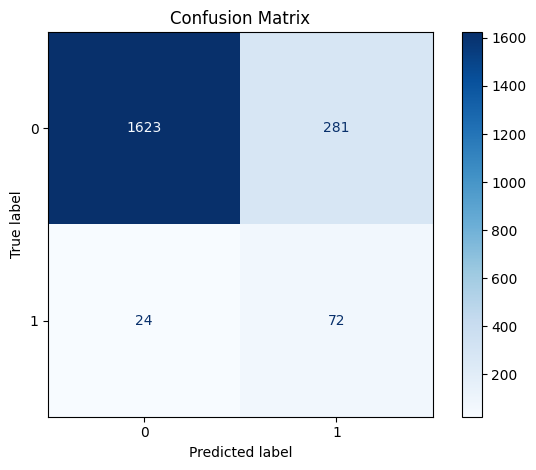

In [ ]:
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation ─────────────────────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

FEATURE IMPORTANCE

weight : how many times a feature is used to split across all trees

gain   : average improvement in loss when a feature is used to split  ← most informative

cover  : average number of samples affected by splits on this feature


── Feature Importance (gain) ────────────────────────────────────
dpd_90_count_24m                       261.083527
dpd_60_count_12m                       198.903107
emi_bounce_count_12m                   174.874420
monthly_income                         138.560272
dpd_30_count_12m                       130.319290
ecs_return_count_12m                   125.621040
annual_income                          114.308708
credit_utilization_ratio                93.603020
bureau_score                            92.636681
emi_to_income_ratio                     70.510406
written_off_accounts_count              61.398067
account_vintage_months                  52.249233
customer_id                             50.995777
total_credit_limit                      49.275970
years_in_current_job                    47.669094
avg_monthly_balance_6m                  47.601776
bureau_vintage_months                   47.145550
recent_enquiry_count_12m                46.672344
age                              

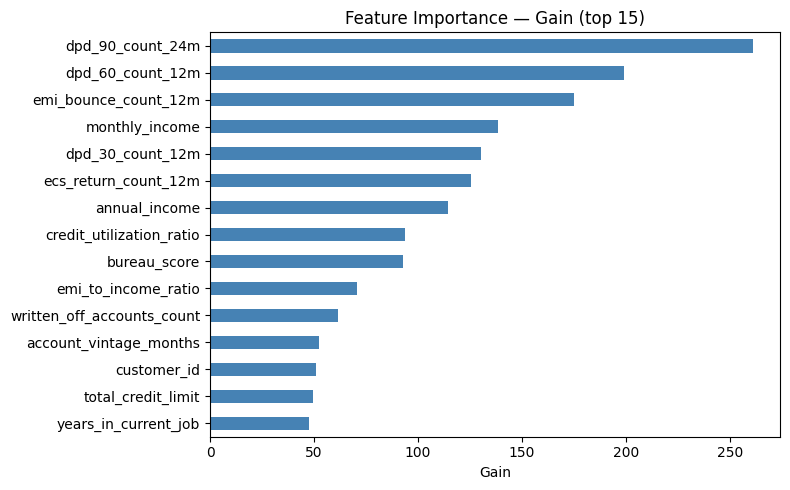

In [ ]:
print("\n── Feature Importance (gain) ────────────────────────────────────")
fi_gain = (pd.Series(best_model.get_booster().get_score(importance_type="gain"))
             .sort_values(ascending=False))
print(fi_gain)

fig, ax = plt.subplots(figsize=(8, 5))
fi_gain.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Gain (top 15)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance_gain.png", dpi=150)
plt.show()

SHAP — SHapley Additive exPlanations
SHAP gives each feature a contribution value *per prediction*, not just globally.
It satisfies game-theoretic fairness axioms and is the gold standard for explainability.


── SHAP Values ──────────────────────────────────────────────────


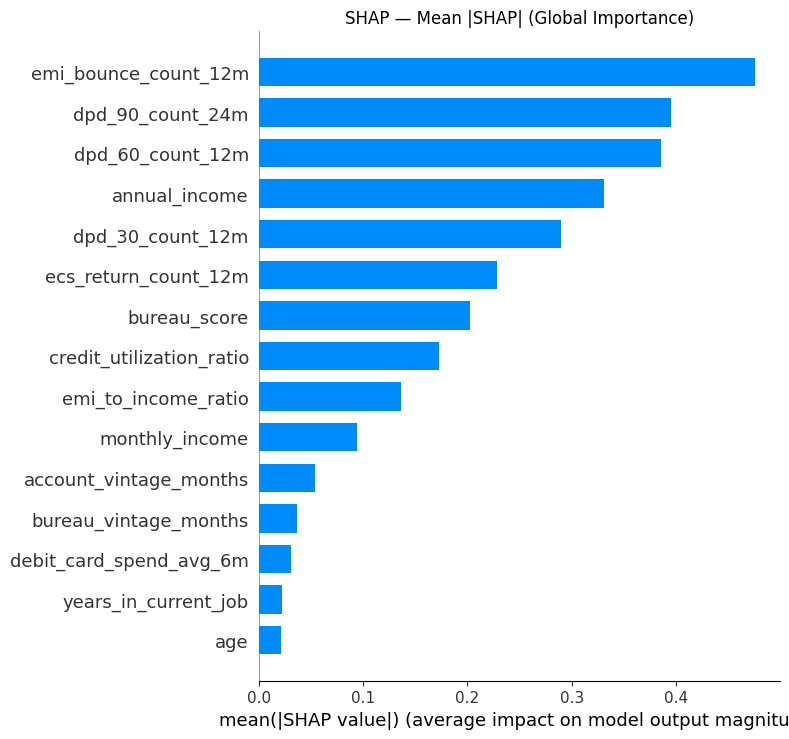

In [ ]:
import shap
from shap import TreeExplainer, waterfall_plot
print("\n── SHAP Values ──────────────────────────────────────────────────")
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Global summary plot (bar = mean |SHAP|)
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| (Global Importance)")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150)
plt.show()

In [ ]:
X_test = X_test.drop(columns=['monthly_income'])

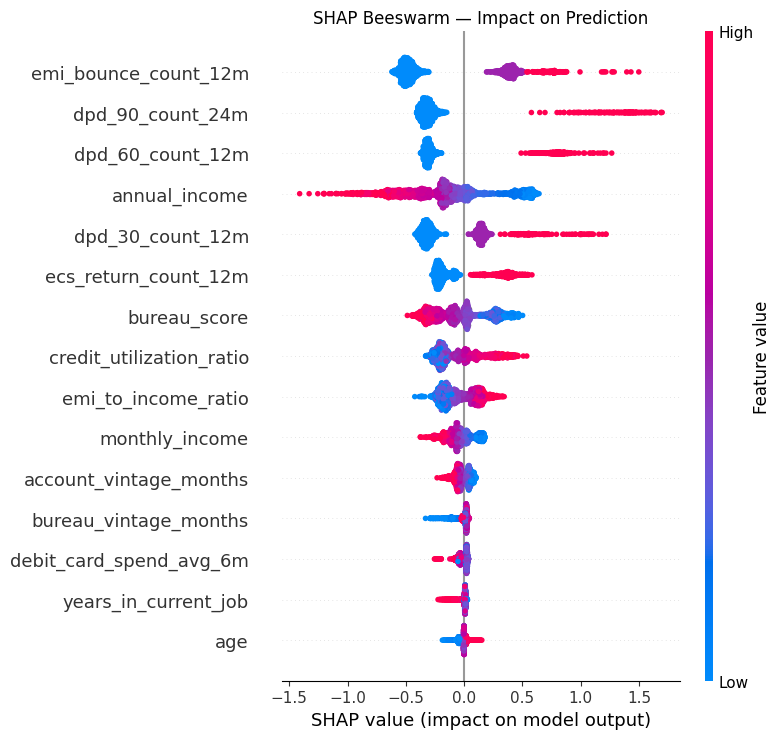

In [ ]:
# Beeswarm plot (shows direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact on Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150)
plt.show()

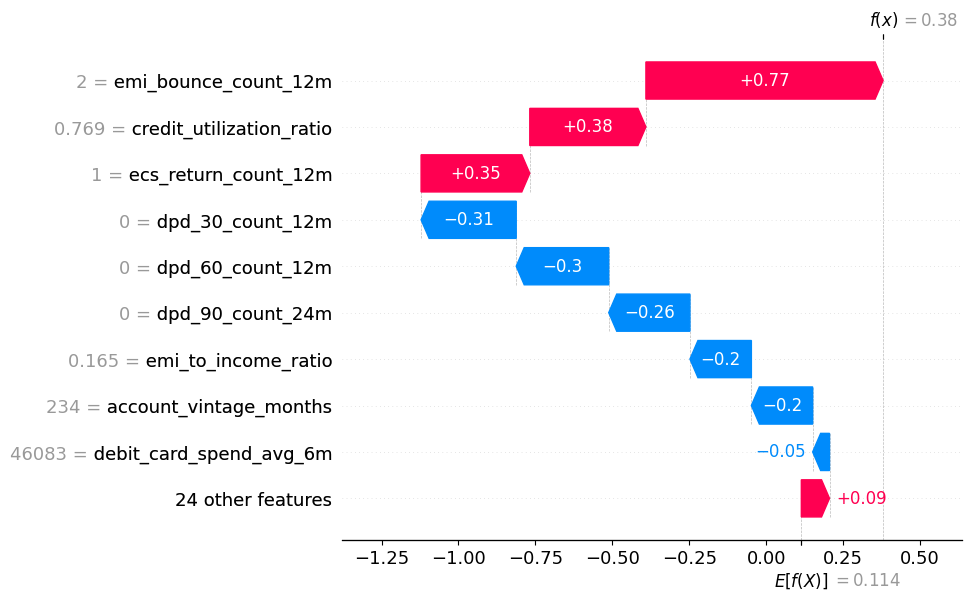

<Figure size 640x480 with 0 Axes>

In [ ]:
# Single prediction explanation (row 0 as example)
shap.waterfall_plot(shap.Explanation(
    values     = shap_values[0],
    base_values= explainer.expected_value,
    data       = X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))
plt.tight_layout()
plt.savefig("shap_waterfall_row0.png", dpi=150)
plt.show()

In [ ]:
9. EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation ─────────────────────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 10. FEATURE IMPORTANCE — Three views
# ─────────────────────────────────────────────────────────────────────────────

# ── (a) Built-in: weight / gain / cover ─────────────────────────────────────
# weight : how many times a feature is used to split across all trees
# gain   : average improvement in loss when a feature is used to split  ← most informative
# cover  : average number of samples affected by splits on this feature

print("\n── Feature Importance (gain) ────────────────────────────────────")
fi_gain = (pd.Series(best_model.get_booster().get_score(importance_type="gain"))
             .sort_values(ascending=False))
print(fi_gain)

fig, ax = plt.subplots(figsize=(8, 5))
fi_gain.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Gain (top 15)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance_gain.png", dpi=150)
plt.show()

# ── (b) SHAP — SHapley Additive exPlanations ────────────────────────────────
# SHAP gives each feature a contribution value *per prediction*, not just globally.
# It satisfies game-theoretic fairness axioms and is the gold standard for explainability.

print("\n── SHAP Values ──────────────────────────────────────────────────")
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Global summary plot (bar = mean |SHAP|)
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| (Global Importance)")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150)
plt.show()

# Beeswarm plot (shows direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact on Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150)
plt.show()

# Single prediction explanation (row 0 as example)
shap.waterfall_plot(shap.Explanation(
    values     = shap_values[0],
    base_values= explainer.expected_value,
    data       = X_test.iloc[0],
    feature_names=selected_features
))
plt.tight_layout()
plt.savefig("shap_waterfall_row0.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 11. SAVE MODEL + FREQUENCY MAPS
# ─────────────────────────────────────────────────────────────────────────────
import json, pickle

best_model.save_model("xgboost_model.json")   # portable JSON format
print("\nModel saved → xgboost_model.json")

with open("freq_maps.pkl", "wb") as f:
    pickle.dump(freq_maps, f)
print("Frequency maps saved → freq_maps.pkl")

# ── How to load & score new data at inference ────────────────────────────────
# model = xgb.XGBClassifier()
# model.load_model("xgboost_model.json")
#
# with open("freq_maps.pkl", "rb") as f:
#     freq_maps = pickle.load(f)
#
# # Apply same frequency encoding
# for col, fmap in freq_maps.items():
#     new_df[col] = new_df[col].map(fmap).fillna(0)
#
# preds = model.predict_proba(new_df[selected_features])[:, 1]

print("\n✅ Pipeline complete.")

SAVE THE MODEL

In [ ]:
import json, pickle

best_model.save_model("xgboost_model.json")   # portable JSON format
print("\nModel saved → xgboost_model.json")


Model saved → xgboost_model.json
